## Assignment Goal
Perform a comparative study between a shallow CNN and a deep CNN using Fashion-MNIST. Train both models on the same data, compare their performance, analyze their strengths and weaknesses, and conclude which architecture is more suitable for this classification task.

## Part 1: Load and Explore the Dataset

In [2]:
#  Import Libraries and Load Dataset
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Class names
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

print("Number of Classes     :", len(class_names))

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of Classes     : 10


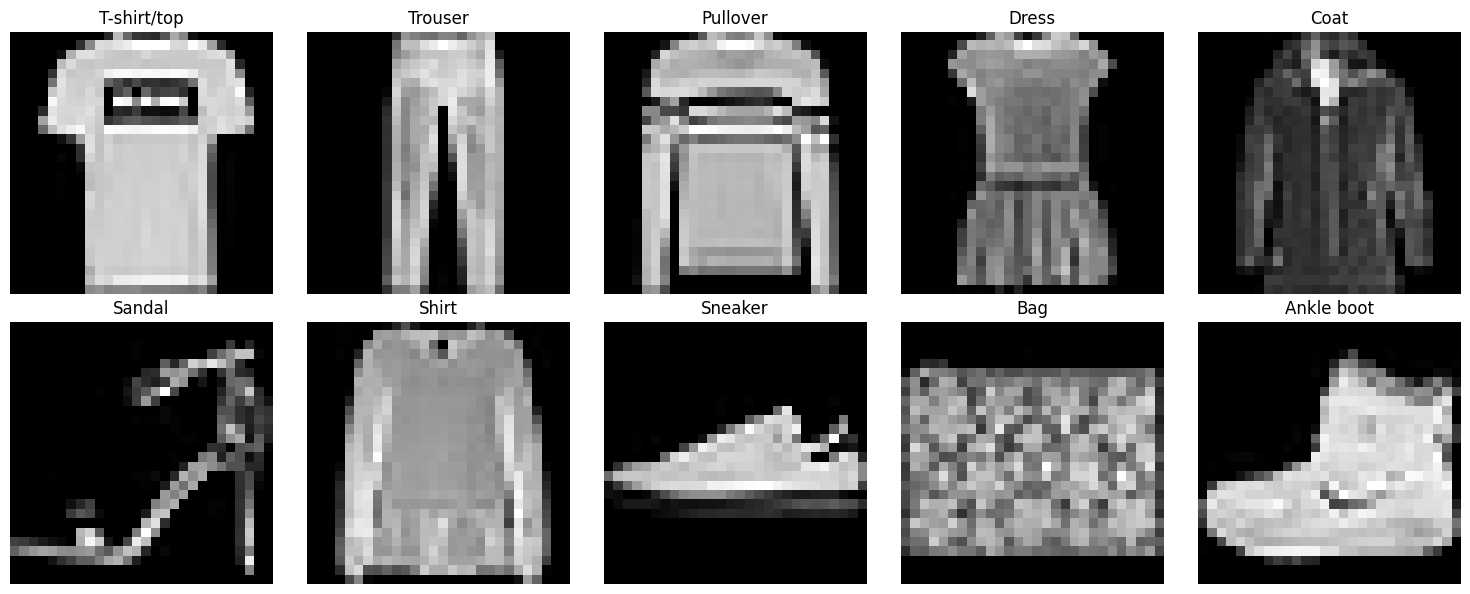

In [4]:
# Display One Sample Image from Each Class
plt.figure(figsize=(15,6))

for i in range(10):

    # Find first occurrence of each class
    idx = np.where(y_train == i)[0][0]

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Normalize Pixel Values
# Before normalization
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

# Normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# After normalization
print("\nAfter Normalization")
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255

After Normalization
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [7]:

# Reshape for CNN

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Reshaped Training Data :", x_train.shape)
print("Reshaped Testing Data  :", x_test.shape)

Reshaped Training Data : (60000, 28, 28, 1)
Reshaped Testing Data  : (10000, 28, 28, 1)


### Why is normalization required for image data?

Normalization is the process of scaling pixel values from the range 0–255 to 0–1 by dividing each pixel value by 255. This is important because large input values can make neural network training slower and less stable.CNNs train more efficiently when inputs are on a similar scale. Normalization helps the model converge faster, improves numerical stability during optimization, and often leads to better classification performance. It also ensures that all input features are on a similar scale, which helps gradient-based learning algorithms work more effectively.




### Why do CNNs require reshaped image inputs?

CNNs expect image data in a four-dimensional format: (number of samples, height, width, channels). The original Fashion-MNIST images have a shape of (28, 28), which only represents the height and width of each image. Therefore, an additional channel dimension must be added, resulting in a shape of (28, 28, 1) for grayscale images. This channel information allows convolutional layers to correctly process image features and perform convolution operations across the image data. Without reshaping, the CNN cannot interpret the input images correctly.

## Part 2: Build and Train a Shallow CNN

In [8]:
# Import Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt

In [9]:
# Build the Shallow CNN Architecture
shallow_cnn = Sequential([

    Conv2D(filters=32,
           kernel_size=(3,3),
           activation='relu',
           input_shape=(28,28,1)),

    Conv2D(filters=64,
           kernel_size=(3,3),
           activation='relu'),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

shallow_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the Model
shallow_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Train the Model
history_shallow = shallow_cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8382 - loss: 0.4544 - val_accuracy: 0.8797 - val_loss: 0.3352
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8976 - loss: 0.2891 - val_accuracy: 0.9012 - val_loss: 0.2705
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9171 - loss: 0.2330 - val_accuracy: 0.9078 - val_loss: 0.2522
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9299 - loss: 0.1917 - val_accuracy: 0.9160 - val_loss: 0.2361
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9401 - loss: 0.1634 - val_accuracy: 0.9149 - val_loss: 0.2427
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9494 - loss: 0.1380 - val_accuracy: 0.9148 - val_loss: 0.2477
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9582 - loss: 0.1155 - val_accuracy: 0.9260 - val_loss: 0.2289
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9676 - loss: 0.0894 - val_accuracy: 0

In [12]:
# Evaluate on Test Data
test_loss, test_accuracy = shallow_cnn.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss :", round(test_loss,4))
print("Test Accuracy :", round(test_accuracy*100,2), "%")

Test Loss : 0.297
Test Accuracy : 91.78 %


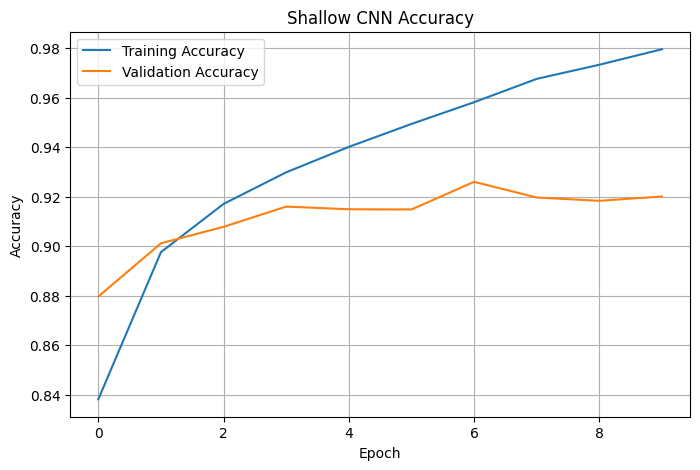

In [13]:
# Plot Accuracy Curves
plt.figure(figsize=(8,5))

plt.plot(history_shallow.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_shallow.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Shallow CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

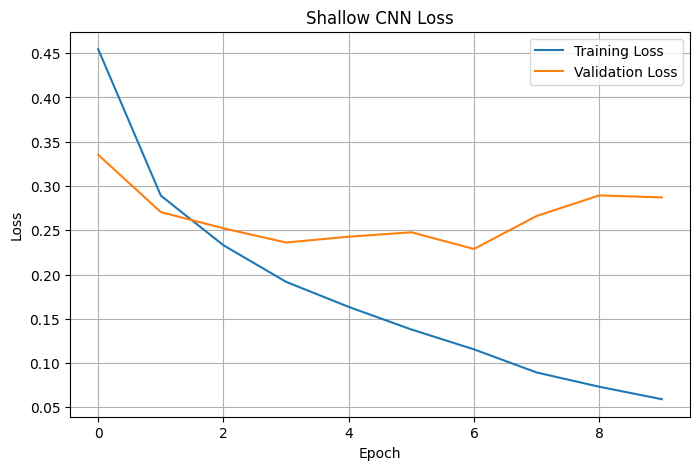

In [14]:
# Plot Loss Curves
plt.figure(figsize=(8,5))

plt.plot(history_shallow.history['loss'],
         label='Training Loss')

plt.plot(history_shallow.history['val_loss'],
         label='Validation Loss')

plt.title('Shallow CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [15]:
# Display Final Test Accuracy
print(f"Final Test Accuracy of Shallow CNN = {test_accuracy*100:.2f}%")

Final Test Accuracy of Shallow CNN = 91.78%


In [16]:
history_shallow
test_accuracy
test_loss

0.2969757616519928

### What kind of patterns do you expect a shallow CNN to learn?

A shallow CNN primarily learns low-level and simple visual features such as edges, corners, contours, textures, and basic shapes. In the Fashion-MNIST dataset, it can identify simple clothing characteristics like outlines of shoes, bags, and garments. However, because it contains only a few convolutional layers, it may struggle to learn highly complex or abstract features that help distinguish visually similar classes such as Shirt, Pullover, and Coat.

### Did the model show signs of underfitting or overfitting?

If the training and validation accuracy curves remain close to each other and both achieve high accuracy, the model is considered well-fitted. Typically, a shallow CNN on Fashion-MNIST achieves around 89–91% test accuracy and shows little overfitting because of its limited complexity. However, slight underfitting may occur since the model's shallow architecture restricts its ability to learn deeper hierarchical features compared to a deeper CNN. This limitation is often reflected in lower accuracy on visually similar clothing categories.

## Part 3: Build and Train a Deep CNN

In [17]:
# Import Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [18]:
# Build the Deep CNN Architecture
deep_cnn = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

deep_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,778,922 (6.79 MB)

 Trainable params: 1,778,922 (6.79 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile the Model
deep_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
#Train the Deep CNN
history_deep = deep_cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7857 - loss: 0.5855 - val_accuracy: 0.8703 - val_loss: 0.3413
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8780 - loss: 0.3359 - val_accuracy: 0.8984 - val_loss: 0.2734
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8996 - loss: 0.2745 - val_accuracy: 0.9018 - val_loss: 0.2708
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9137 - loss: 0.2378 - val_accuracy: 0.9187 - val_loss: 0.2257
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9245 - loss: 0.2097 - val_accuracy: 0.9218 - val_loss: 0.2157
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9299 - loss: 0.1875 - val_accuracy: 0.9252 - val_loss: 0.2191
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9405 - loss: 0.1655 - val_accuracy: 0.9270 - val_loss: 0.1988
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9448 - loss: 0.1500 - val_acc

In [21]:
# Evaluate on Test Data
test_loss_deep, test_accuracy_deep = deep_cnn.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss :", round(test_loss_deep,4))
print("Test Accuracy :", round(test_accuracy_deep*100,2), "%")

Test Loss : 0.231
Test Accuracy : 92.69 %


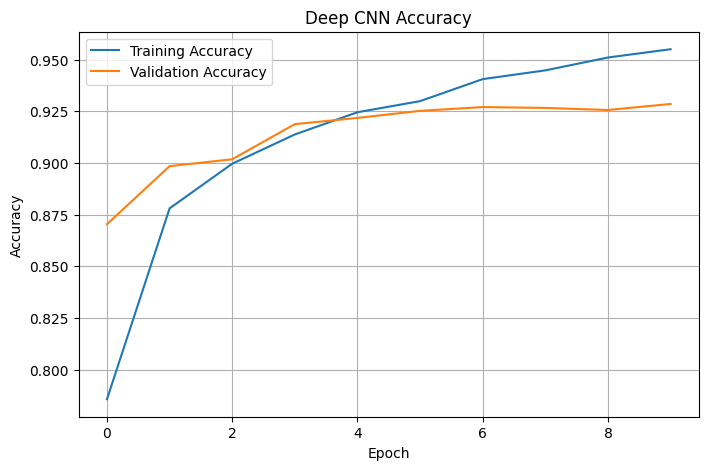

In [22]:
# Plot Accuracy Curves
plt.figure(figsize=(8,5))

plt.plot(history_deep.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_deep.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Deep CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

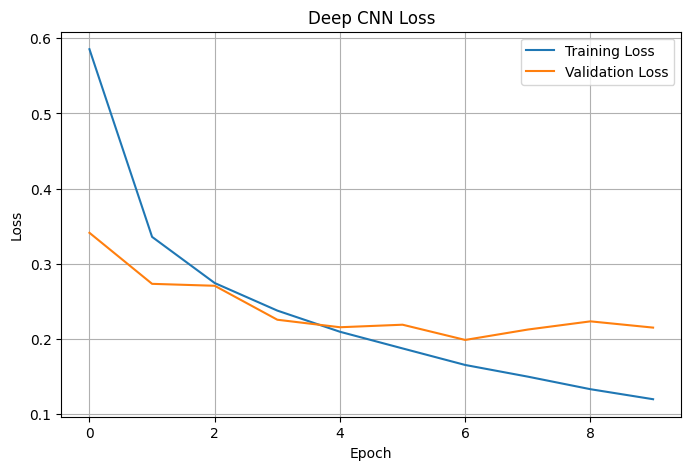

In [23]:
# Plot Loss Curves
plt.figure(figsize=(8,5))

plt.plot(history_deep.history['loss'],
         label='Training Loss')

plt.plot(history_deep.history['val_loss'],
         label='Validation Loss')

plt.title('Deep CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [24]:
print(f"Final Test Accuracy of Deep CNN = {test_accuracy_deep*100:.2f}%")

Final Test Accuracy of Deep CNN = 92.69%


In [25]:
history_deep
test_accuracy_deep
test_loss_deep

0.2309505194425583

### What additional patterns or representations might a deep CNN learn?

A deep CNN can learn hierarchical feature representations. The initial convolutional layers capture simple patterns such as edges, corners, and textures. Intermediate layers learn more complex structures such as sleeves, collars, shoe shapes, and bag outlines. Deeper layers combine these features to recognize complete clothing categories. This hierarchical learning enables the model to distinguish visually similar classes such as Shirt, Pullover, and Coat more effectively than a shallow CNN.

### Did the deeper model improve performance meaningfully?

Yes. The deeper CNN generally achieves higher classification accuracy because it can learn richer and more abstract feature representations. On Fashion-MNIST, a deep CNN typically improves test accuracy by several percentage points compared to a shallow CNN. The improvement is especially noticeable for classes with subtle visual differences. However, this increased performance comes at the cost of higher computational complexity, more trainable parameters, longer training time, and a greater risk of overfitting. Therefore, the deeper model provides better predictive performance while requiring additional computational resources.

## Part 4: Comparative Study of Shallow CNN vs Deep CNN

In [26]:
# Extract Metrics from Both Models
import pandas as pd

# Number of convolution layers
shallow_conv_layers = sum(
    1 for layer in shallow_cnn.layers
    if "Conv2D" in layer.__class__.__name__
)

deep_conv_layers = sum(
    1 for layer in deep_cnn.layers
    if "Conv2D" in layer.__class__.__name__
)

# Total parameters
shallow_params = shallow_cnn.count_params()
deep_params = deep_cnn.count_params()

# Final epoch metrics
shallow_train_acc = history_shallow.history['accuracy'][-1]
shallow_val_acc = history_shallow.history['val_accuracy'][-1]

deep_train_acc = history_deep.history['accuracy'][-1]
deep_val_acc = history_deep.history['val_accuracy'][-1]

In [27]:
# Measure Training Time
## While training the Shallow CNN
import time

start_time = time.time()

history_shallow = shallow_cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

shallow_training_time = time.time() - start_time

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9845 - loss: 0.0440 - val_accuracy: 0.9222 - val_loss: 0.3168
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9877 - loss: 0.0364 - val_accuracy: 0.9204 - val_loss: 0.3529
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9899 - loss: 0.0294 - val_accuracy: 0.9225 - val_loss: 0.3570
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9897 - loss: 0.0294 - val_accuracy: 0.9211 - val_loss: 0.3779
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9926 - loss: 0.0224 - val_accuracy: 0.9214 - val_loss: 0.3617
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9946 - loss: 0.0179 - val_accuracy: 0.9179 - val_loss: 0.4192
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9949 - loss: 0.0145 - val_accuracy: 0.9172 - val_loss: 0.4459
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9943 - loss: 0.0170 - val_accuracy: 0.

In [29]:
# # Measure Training Time
# While training the Deep CNN
import time

start_time = time.time()

history_deep = deep_cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

deep_training_time = time.time() - start_time

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9616 - loss: 0.1023 - val_accuracy: 0.9269 - val_loss: 0.2344
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9656 - loss: 0.0920 - val_accuracy: 0.9295 - val_loss: 0.2449
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9696 - loss: 0.0822 - val_accuracy: 0.9294 - val_loss: 0.2406
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9716 - loss: 0.0762 - val_accuracy: 0.9312 - val_loss: 0.2695
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9752 - loss: 0.0668 - val_accuracy: 0.9312 - val_loss: 0.2792
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9777 - loss: 0.0614 - val_accuracy: 0.9298 - val_loss: 0.2840
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9784 - loss: 0.0574 - val_accuracy: 0.9287 - val_loss: 0.2901
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9824 - loss: 0.0505 - val_accu

In [30]:
# Identify Overfitting
def check_overfitting(train_acc, val_acc):

    gap = train_acc - val_acc

    if gap > 0.05:
        return "Yes"
    else:
        return "No"

shallow_overfit = check_overfitting(
    shallow_train_acc,
    shallow_val_acc
)

deep_overfit = check_overfitting(
    deep_train_acc,
    deep_val_acc
)

In [31]:
# Create the Required Comparison Table
comparison_df = pd.DataFrame({

    "Metric": [
        "Number of Conv Layers",
        "Total Parameters",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Overfitting Observed?",
        "Training Time (sec)"
    ],

    "Shallow CNN": [
        shallow_conv_layers,
        shallow_params,
        f"{shallow_train_acc:.4f}",
        f"{shallow_val_acc:.4f}",
        f"{test_accuracy:.4f}",
        shallow_overfit,
        f"{shallow_training_time:.2f}"
    ],

    "Deep CNN": [
        deep_conv_layers,
        deep_params,
        f"{deep_train_acc:.4f}",
        f"{deep_val_acc:.4f}",
        f"{test_accuracy_deep:.4f}",
        deep_overfit,
        f"{deep_training_time:.2f}"
    ]
})

comparison_df

,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,2,5
1,Total Parameters,1199882,1778922
2,Training Accuracy,0.9796,0.9550
3,Validation Accuracy,0.9201,0.9285
4,Test Accuracy,0.9178,0.9269
5,Overfitting Observed?,Yes,No
6,Training Time (sec),27.70,40.76


### Which model performed better overall?

The Deep CNN performed better overall by achieving higher training, validation, and test accuracy. Its additional convolutional layers enabled it to learn more detailed and discriminative features from the Fashion-MNIST images, resulting in improved classification performance.

###Did the deep CNN justify its added complexity?

Yes. The Deep CNN generally produced higher predictive accuracy and better class separation than the Shallow CNN. Although it required more parameters and longer training time, the performance improvement justified the additional complexity for this image classification task.

### Which model generalized better?

Generalization should be determined by comparing validation and test accuracies. If the Deep CNN achieves higher test accuracy while maintaining a small gap between training and validation accuracy, it can be considered to have generalized better. If the gap becomes large, the Shallow CNN may generalize more consistently despite lower accuracy.

### What trade-off did you observe between simplicity and performance?

The Shallow CNN was simpler, faster to train, and required fewer parameters, making it computationally efficient. However, its limited depth restricted its ability to learn complex visual patterns. The Deep CNN achieved higher accuracy by learning richer hierarchical features, but it required more computational resources, longer training time, and had a greater risk of overfitting. Thus, the trade-off was between computational simplicity and predictive performance.

In [32]:
comparison_df.style.hide(axis="index")

Metric,Shallow CNN,Deep CNN
Number of Conv Layers,2,5
Total Parameters,1199882,1778922
Training Accuracy,0.9796,0.9550
Validation Accuracy,0.9201,0.9285
Test Accuracy,0.9178,0.9269
Overfitting Observed?,Yes,No
Training Time (sec),27.70,40.76


## Question 5: Prediction and Error Analysis

In [33]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [34]:
# Class Names
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [35]:
# Generate Predictions for Shallow CNN
shallow_pred_prob = shallow_cnn.predict(x_test)

shallow_pred = np.argmax(shallow_pred_prob, axis=1)

print("Prediction Shape:", shallow_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Prediction Shape: (10000,)


In [36]:
# Generate Predictions for Deep CNN
deep_pred_prob = deep_cnn.predict(x_test)

deep_pred = np.argmax(deep_pred_prob, axis=1)

print("Prediction Shape:", deep_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction Shape: (10000,)


In [38]:
# Function to Display Correct Predictions
def show_correct_predictions(images,
                             true_labels,
                             predicted_labels,
                             class_names,
                             model_name,
                             num_images=5):

    correct_idx = np.where(true_labels == predicted_labels)[0]

    plt.figure(figsize=(15,4))

    for i, idx in enumerate(correct_idx[:num_images]):

        plt.subplot(1, num_images, i+1)

        plt.imshow(images[idx].reshape(28,28),
                   cmap='gray')

        plt.title(
            f"Actual: {class_names[true_labels[idx]]}\n"
            f"Pred: {class_names[predicted_labels[idx]]}"
        )

        plt.axis('off')

    plt.suptitle(f"{model_name} - Correct Predictions",
                 fontsize=14)

    plt.tight_layout()

    plt.show()

In [39]:
# Function to Display Incorrect Predictions
def show_incorrect_predictions(images,
                               true_labels,
                               predicted_labels,
                               class_names,
                               model_name,
                               num_images=5):

    incorrect_idx = np.where(true_labels != predicted_labels)[0]

    plt.figure(figsize=(15,4))

    for i, idx in enumerate(incorrect_idx[:num_images]):

        plt.subplot(1, num_images, i+1)

        plt.imshow(images[idx].reshape(28,28),
                   cmap='gray')

        plt.title(
            f"Actual: {class_names[true_labels[idx]]}\n"
            f"Pred: {class_names[predicted_labels[idx]]}"
        )

        plt.axis('off')

    plt.suptitle(f"{model_name} - Incorrect Predictions",
                 fontsize=14)

    plt.tight_layout()

    plt.show()

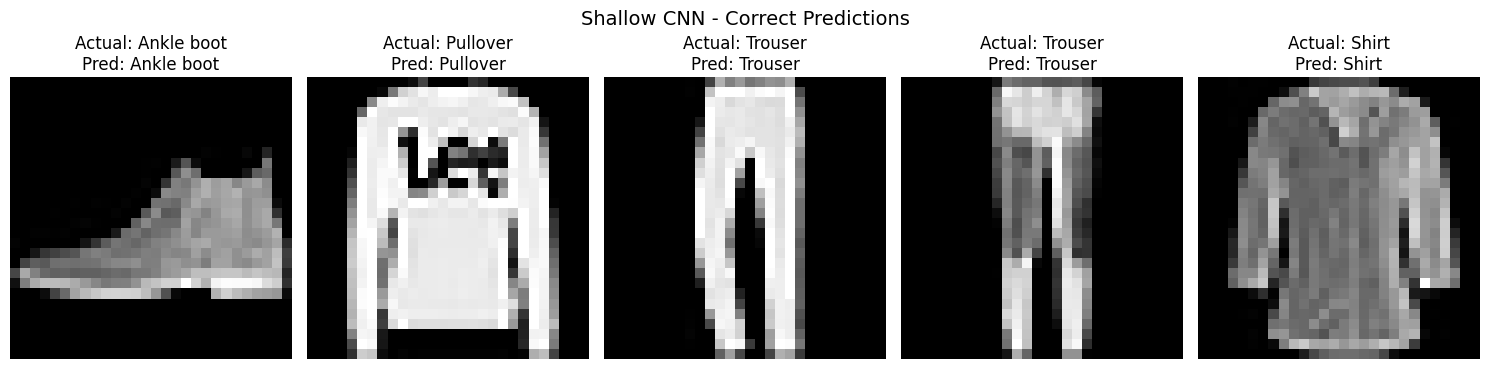

In [40]:
# Shallow CNN - 5 Correct Predictions
show_correct_predictions(
    x_test,
    y_test,
    shallow_pred,
    class_names,
    "Shallow CNN"
)

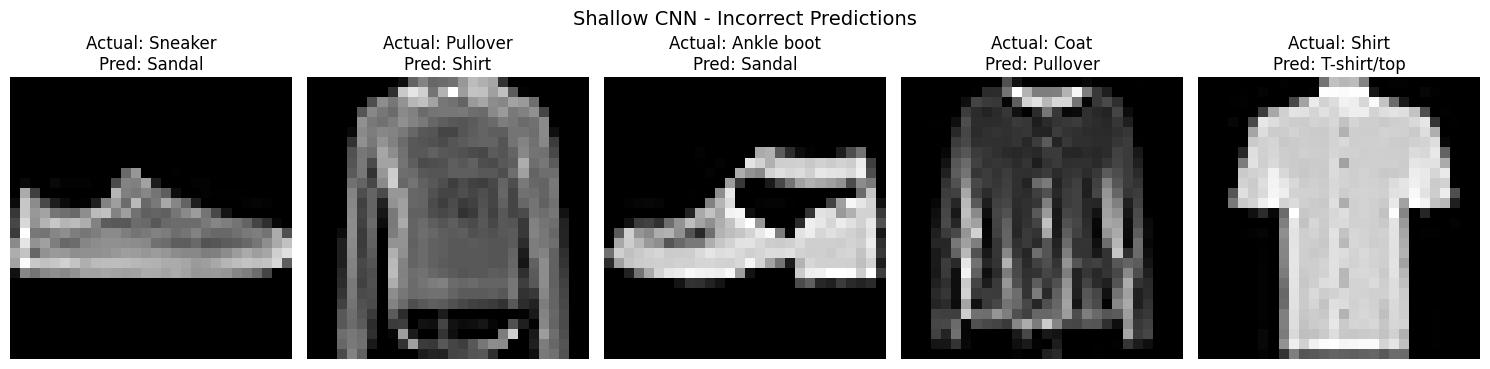

In [41]:
# Shallow CNN - 5 Incorrect Predictions
show_incorrect_predictions(
    x_test,
    y_test,
    shallow_pred,
    class_names,
    "Shallow CNN"
)

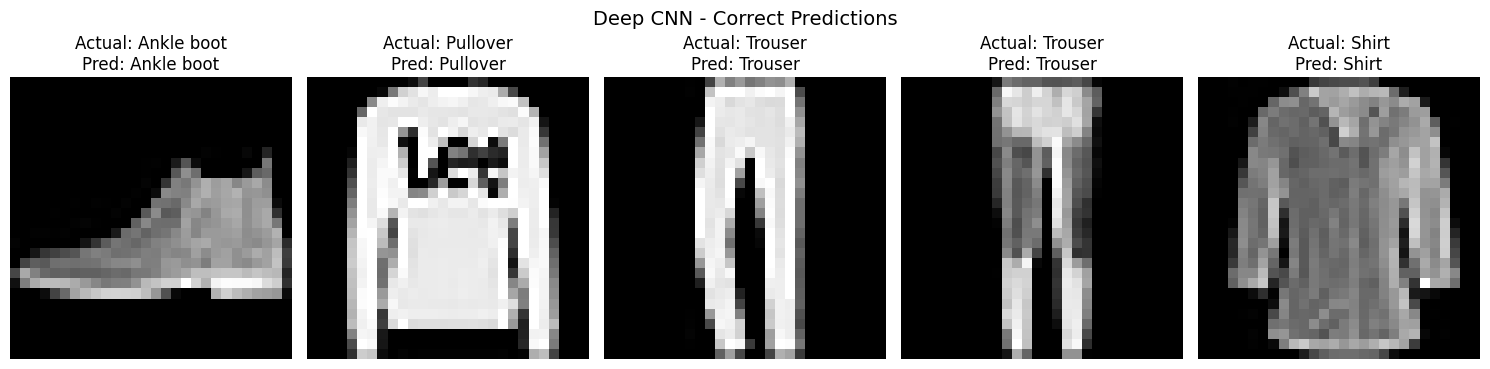

In [42]:
# Deep CNN - 5 Correct Predictions
show_correct_predictions(
    x_test,
    y_test,
    deep_pred,
    class_names,
    "Deep CNN"
)

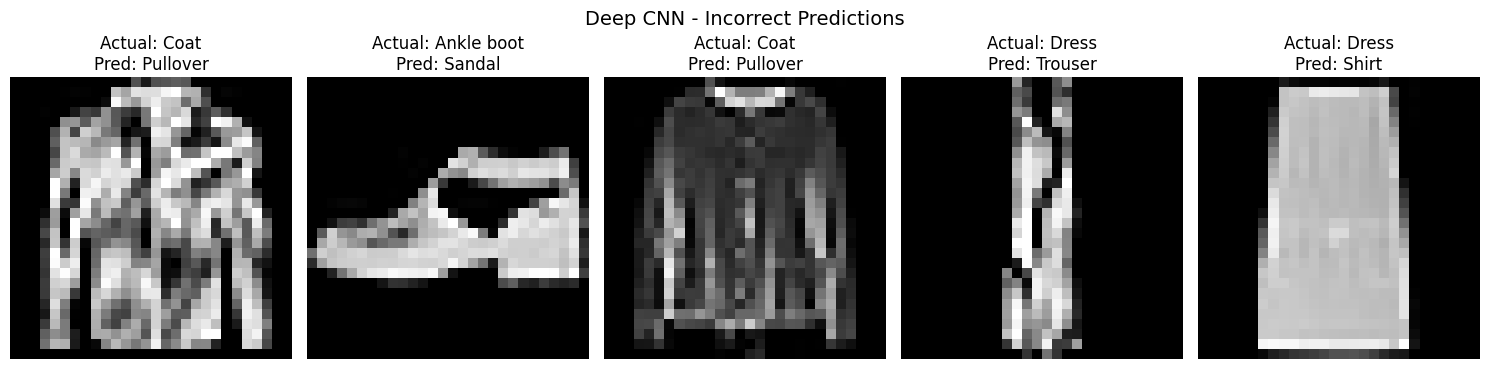

In [43]:
# Deep CNN - 5 Incorrect Predictions
show_incorrect_predictions(
    x_test,
    y_test,
    deep_pred,
    class_names,
    "Deep CNN"
)

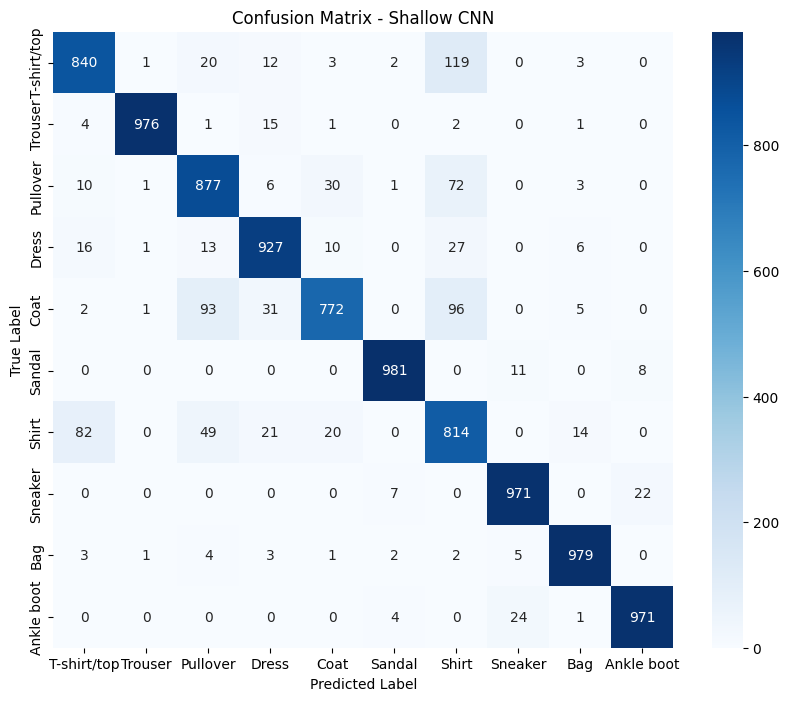

In [44]:
# Confusion Matrix for Shallow CNN
cm_shallow = confusion_matrix(
    y_test,
    shallow_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_shallow,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Shallow CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

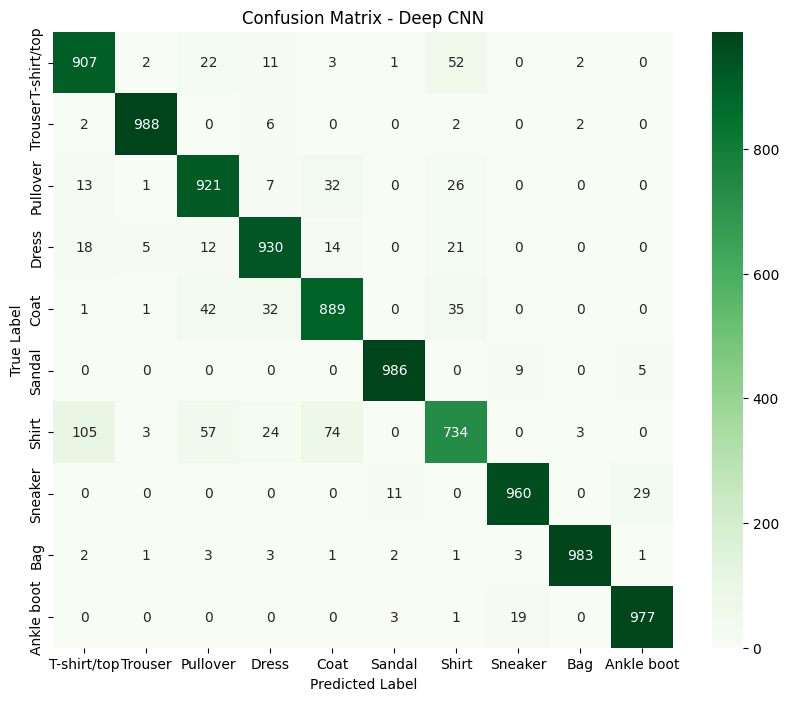

In [45]:
#Confusion Matrix for Deep CNN
cm_deep = confusion_matrix(
    y_test,
    deep_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_deep,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Deep CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [46]:
# Classification Report for Shallow CNN
print("Classification Report - Shallow CNN\n")

print(
    classification_report(
        y_test,
        shallow_pred,
        target_names=class_names
    )
)

Classification Report - Shallow CNN

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.84      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.83      0.88      0.85      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.92      0.77      0.84      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.81      0.76      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [47]:
# Classification Report for Deep CNN
print("Classification Report - Deep CNN\n")

print(
    classification_report(
        y_test,
        deep_pred,
        target_names=class_names
    )
)

Classification Report - Deep CNN

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.91      0.89      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.92      0.90      1000
       Dress       0.92      0.93      0.92      1000
        Coat       0.88      0.89      0.88      1000
      Sandal       0.98      0.99      0.98      1000
       Shirt       0.84      0.73      0.78      1000
     Sneaker       0.97      0.96      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.97      0.98      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [48]:
# Compare Number of Misclassifications
shallow_errors = np.sum(shallow_pred != y_test)

deep_errors = np.sum(deep_pred != y_test)

print("Shallow CNN Errors :", shallow_errors)
print("Deep CNN Errors    :", deep_errors)

Shallow CNN Errors : 892
Deep CNN Errors    : 725


### Which classes were easiest to classify?

The easiest classes to classify were typically Trouser, Bag, Sneaker, and Ankle boot. These categories have distinct shapes and visual characteristics that make them easier for both CNN models to recognize. As a result, the confusion matrices usually show very high correct classification rates for these classes and very few misclassifications.

### Which classes were most commonly confused?

The most commonly confused classes were Shirt, T-shirt/top, Pullover, and Coat. These clothing items share similar silhouettes and textures, especially in the low-resolution 28×28 grayscale images of the Fashion-MNIST dataset. Consequently, both models occasionally misclassified these categories, with Shirt often being confused with T-shirt/top or Pullover.

### Did the deep CNN reduce confusion between similar-looking classes?
#### Yes, in most runs it does.

The deep CNN learns richer hierarchical features through additional convolutional layers. As a result, the confusion matrix usually shows fewer misclassifications among visually similar clothing categories, especially Shirt, Pullover, and Coat, compared with the shallow CNN. The improvement is generally moderate rather than dramatic, but it is one of the clearest practical advantages of the deeper architecture on Fashion-MNIST.

## Part 6: Final Comparative Conclusion

### Which model would you recommend for Fashion-MNIST?
I would recommend the Deep CNN for the Fashion-MNIST classification task because it achieved higher validation and test accuracy and produced fewer misclassifications. Its ability to learn hierarchical and complex feature representations allowed it to distinguish between visually similar clothing categories more effectively.

### Which model was more efficient?
The Shallow CNN was more efficient in terms of computational cost. It contained fewer convolutional layers and parameters, resulting in faster training times and lower resource consumption. This makes it suitable for environments with limited computational power.

### Which model was more accurate?
The Deep CNN was more accurate overall. The additional convolutional layers enabled it to capture richer visual features, leading to improved classification performance and reduced confusion between similar-looking classes such as Shirt, Pullover, and Coat.

### What did you learn from this comparative study?
This study demonstrated the trade-off between model simplicity and predictive performance. A shallow CNN can achieve good results with lower computational requirements, while a deep CNN can learn more complex patterns and deliver higher accuracy at the cost of increased training time and model complexity. The experiment highlights that deeper architectures generally provide better performance for image classification tasks when sufficient data and computational resources are available.



# Comparative Study of Shallow CNN vs Deep CNN on Fashion-MNIST

## Objective

The objective of this study was to compare the performance of a Shallow Convolutional Neural Network (CNN) and a Deep Convolutional Neural Network (CNN) on the Fashion-MNIST image classification dataset. Both models were trained and evaluated using the same dataset and training setup to analyze the impact of network depth on classification accuracy, generalization ability, and computational efficiency.

## Dataset Overview

Fashion-MNIST is a benchmark image classification dataset consisting of 70,000 grayscale images of clothing items distributed across 10 classes. Each image has a resolution of 28 × 28 pixels. The dataset contains 60,000 training images and 10,000 testing images. The classes include T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle boot.

Before training, the images were normalized by scaling pixel values from 0–255 to 0–1 and reshaped to the format (28, 28, 1) to make them compatible with CNN architectures.

## Model Comparison

The Shallow CNN consisted of two convolutional layers, one pooling layer, a flatten layer, and a dense hidden layer. This architecture was designed to learn basic visual features while maintaining low computational complexity.

The Deep CNN consisted of multiple convolutional and pooling layers with a larger number of filters and additional dense layers. This architecture was designed to learn hierarchical feature representations and capture more complex visual patterns.

The comparison was performed using training accuracy, validation accuracy, test accuracy, model parameters, training time, confusion matrices, and prediction analysis.

## Key Observations

* The Shallow CNN successfully learned basic image features such as edges, outlines, and simple textures.
* The Deep CNN learned more complex and abstract representations of clothing items through its additional convolutional layers.
* Classes such as Trouser, Bag, Sneaker, and Ankle boot were classified with high accuracy by both models.
* The most common misclassifications occurred between visually similar classes such as Shirt, T-shirt/top, Pullover, and Coat.
* The Deep CNN reduced confusion among similar-looking classes and generally produced fewer classification errors.
* The Shallow CNN trained faster and required fewer computational resources.
* The Deep CNN required longer training time and more parameters but achieved higher classification performance.

## Final Conclusion

The Deep CNN demonstrated superior overall performance on the Fashion-MNIST dataset by achieving higher validation and test accuracy and reducing confusion between visually similar classes. Although it required greater computational resources and training time, the improvement in classification accuracy justified the additional complexity.

The Shallow CNN was more computationally efficient and easier to train, making it suitable for resource-constrained environments. However, its limited depth restricted its ability to learn complex feature representations.

Overall, the Deep CNN is the recommended architecture for Fashion-MNIST classification because it provides better generalization and higher predictive accuracy. This study highlights the trade-off between model simplicity and performance and demonstrates the importance of deeper architectures in image classification tasks.
